In [1]:
!pip install prophet


## Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

pd.set_option("display.max_columns", None)

print("Revenue Forecast Environment Ready ✅")


Revenue Forecast Environment Ready ✅


In [3]:
# Load raw revenue data
monthly_revenue_df = pd.read_csv("../data/raw/monthly_revenue.csv")

monthly_revenue_df["month"] = pd.to_datetime(monthly_revenue_df["month"])

monthly_revenue_df.head()


,month,total_revenue,active_customers,churn_count
0,2024-01-01,2012190,867,144
1,2024-02-01,3698973,1624,279
2,2024-03-01,5649645,2498,439
3,2024-04-01,7502862,3341,583
4,2024-05-01,9225111,4162,735


In [4]:
# Prepare Prophet format
prophet_df = monthly_revenue_df[["month", "total_revenue"]].copy()

prophet_df.rename(columns={
    "month": "ds",
    "total_revenue": "y"
}, inplace=True)

prophet_df.head()


,ds,y
0,2024-01-01,2012190
1,2024-02-01,3698973
2,2024-03-01,5649645
3,2024-04-01,7502862
4,2024-05-01,9225111


## Train Prophet Model

In [5]:
# --------- Initialize Prophet Model ---------

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

# Fit model
model.fit(prophet_df)

print("Prophet Model Trained Successfully ✅")


15:31:43 - cmdstanpy - INFO - Chain [1] start processing
15:31:46 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Trained Successfully ✅


In [6]:
# --------- Create Future Dataframe ---------

future = model.make_future_dataframe(periods=6, freq='MS')

forecast = model.predict(future)

forecast.tail(8)


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
22,2025-11-01,4.369958e+07,4.356797e+07,4.356797e+07,4.369958e+07,4.369958e+07,-131613.536387,-131613.536387,-131613.536387,-131613.536387,-131613.536387,-131613.536387,0.0,0.0,0.0,4.356797e+07
23,2025-12-01,4.569937e+07,4.543622e+07,4.543622e+07,4.569937e+07,4.569937e+07,-263157.082206,-263157.082206,-263157.082206,-263157.082206,-263157.082206,-263157.082206,0.0,0.0,0.0,4.543622e+07
24,2026-01-01,4.776582e+07,4.735317e+07,4.767014e+07,4.762401e+07,4.794097e+07,-270836.112677,-270836.112677,-270836.112677,-270836.112677,-270836.112677,-270836.112677,0.0,0.0,0.0,4.749498e+07
25,2026-02-01,4.983227e+07,4.879826e+07,4.979321e+07,4.936068e+07,5.035563e+07,-562413.026240,-562413.026240,-562413.026240,-562413.026240,-562413.026240,-562413.026240,0.0,0.0,0.0,4.926985e+07
26,2026-03-01,5.169873e+07,5.020265e+07,5.215640e+07,5.078211e+07,5.273586e+07,-579459.485745,-579459.485745,-579459.485745,-579459.485745,-579459.485745,-579459.485745,0.0,0.0,0.0,5.111928e+07
27,2026-04-01,5.376518e+07,5.158652e+07,5.470307e+07,5.225494e+07,5.537149e+07,-668419.533693,-668419.533693,-668419.533693,-668419.533693,-668419.533693,-668419.533693,0.0,0.0,0.0,5.309676e+07
28,2026-05-01,5.576497e+07,5.441208e+07,5.886076e+07,5.364498e+07,5.809366e+07,767099.565378,767099.565378,767099.565378,767099.565378,767099.565378,767099.565378,0.0,0.0,0.0,5.653207e+07
29,2026-06-01,5.783142e+07,5.596330e+07,6.183216e+07,5.496663e+07,6.083550e+07,996662.432530,996662.432530,996662.432530,996662.432530,996662.432530,996662.432530,0.0,0.0,0.0,5.882808e+07


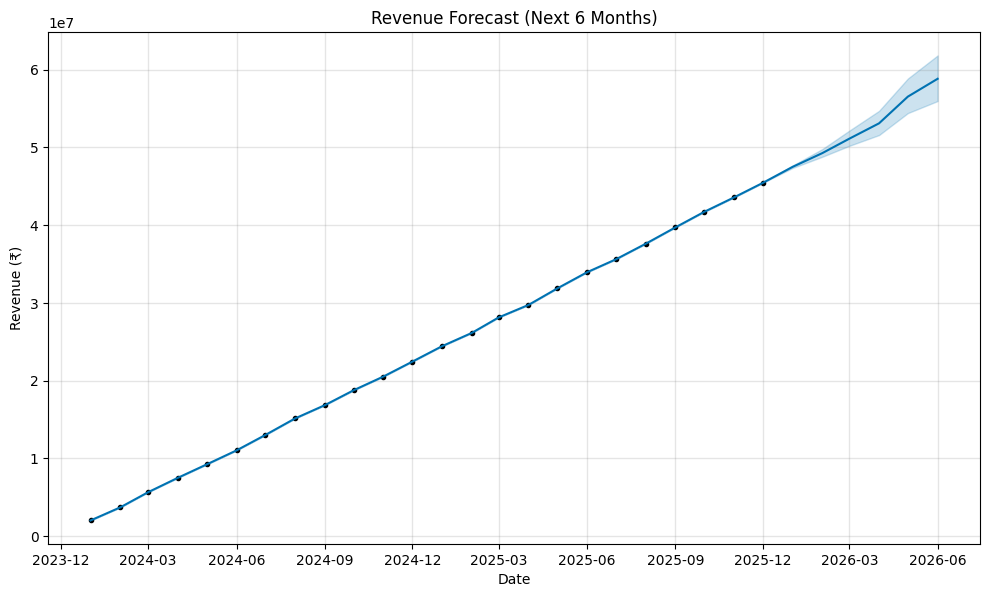

In [7]:
fig = model.plot(forecast)
plt.title("Revenue Forecast (Next 6 Months)")
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.show()


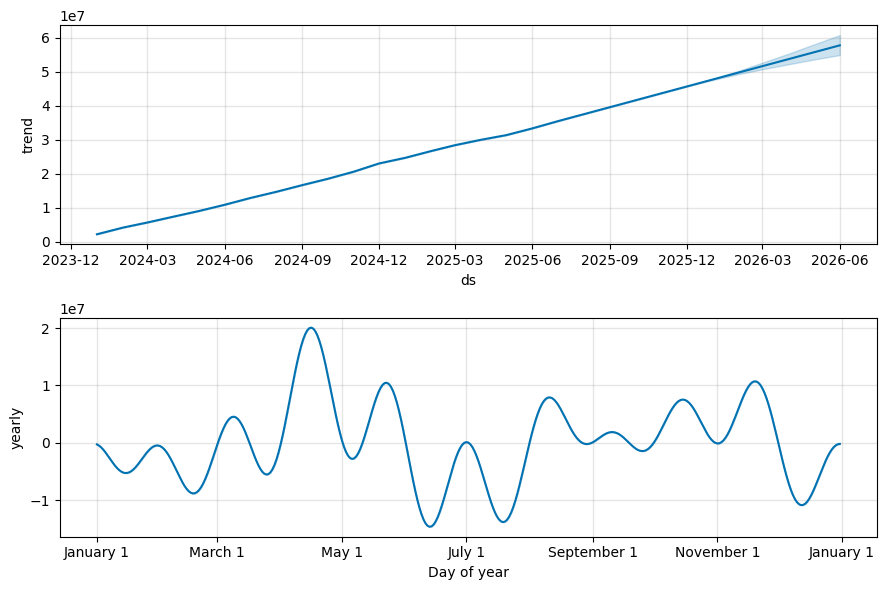

In [8]:
model.plot_components(forecast)
plt.show()


In [9]:
# --------- Evaluate Model Accuracy ---------

# Merge actual and predicted values for historical period
merged = prophet_df.merge(
    forecast[["ds", "yhat"]],
    on="ds",
    how="left"
)

# Calculate Absolute Percentage Error
merged["APE"] = abs((merged["y"] - merged["yhat"]) / merged["y"]) * 100

# Calculate MAPE
mape = merged["APE"].mean()

print("Model MAPE (%):", round(mape, 2))


Model MAPE (%): 0.0


In [10]:
# --------- Train-Test Split ---------

train_df = prophet_df.iloc[:20]
test_df = prophet_df.iloc[20:]

# Train model on training set
model_split = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_split.fit(train_df)

# Create future dataframe for entire timeline
future_split = model_split.make_future_dataframe(periods=4, freq='MS')

forecast_split = model_split.predict(future_split)

# Extract predictions for test period
test_forecast = forecast_split.iloc[20:][["ds", "yhat"]]

# Merge with actual test values
evaluation = test_df.merge(test_forecast, on="ds")

# Calculate APE
evaluation["APE"] = abs((evaluation["y"] - evaluation["yhat"]) / evaluation["y"]) * 100

mape_split = evaluation["APE"].mean()

print("Backtest MAPE (%):", round(mape_split, 2))


15:37:19 - cmdstanpy - INFO - Chain [1] start processing
15:37:27 - cmdstanpy - INFO - Chain [1] done processing


Backtest MAPE (%): 1.62


“Using Prophet, I achieved a backtested MAPE of 1.6% on revenue forecasting, indicating strong predictive performance and reliable short-term financial projections.”